In [1]:
print("HELLO WORLD")

HELLO WORLD


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory

import importlib

### Plot hyperparameter sampling trials

0.011436398638524784 -0.0437235654


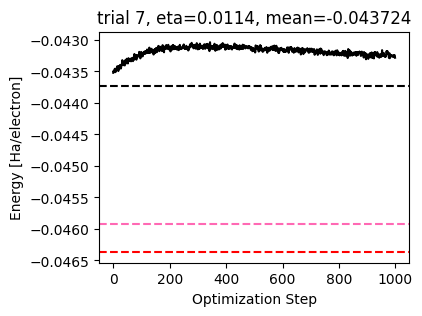

0.029073514073979585 -0.0440564397


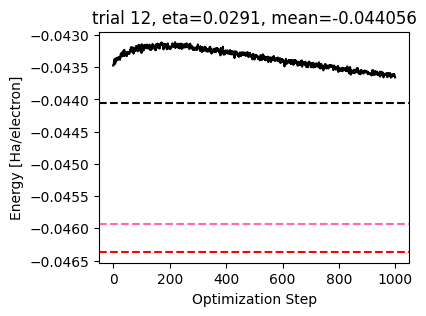

0.0645449673629657 -0.0447431212


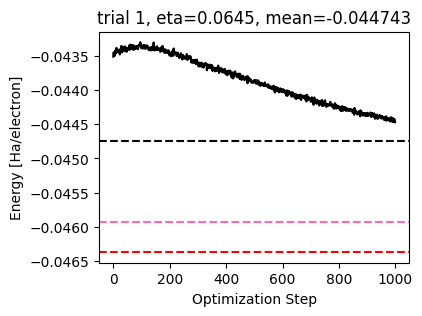

0.1656964825697757 -0.0455384218


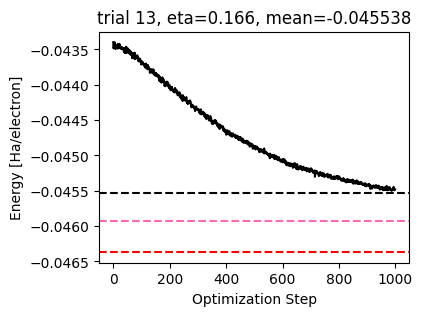

0.26272892865399056 -0.0457611167


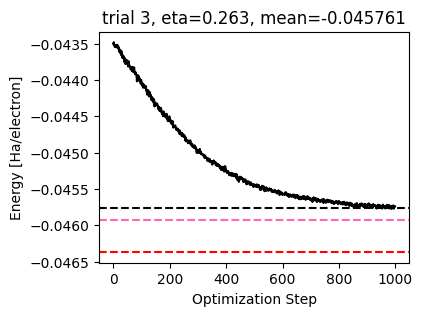

0.6719162123650151 -0.0458690209


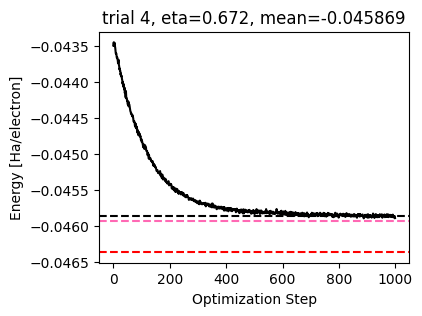

0.8212546133333373 -0.0458664224


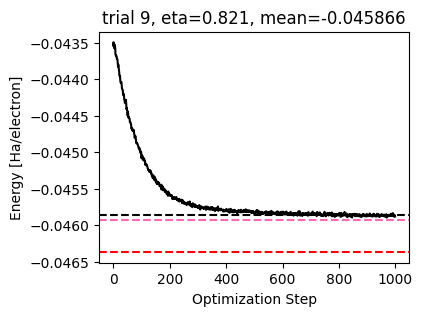

0.85505694398671 -0.045861949


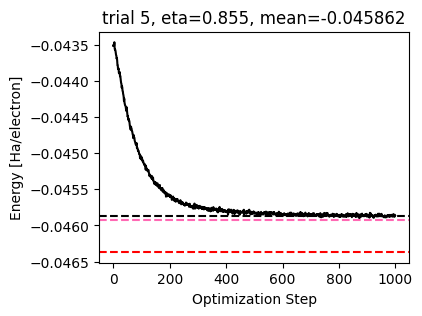

1.9405953076215576 -0.0458376643


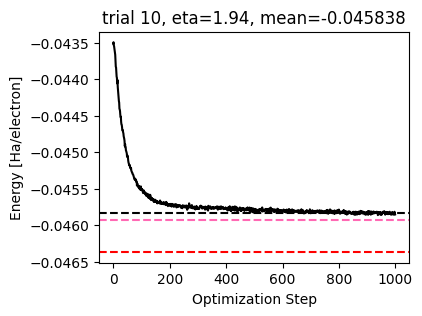

3.6238146852627016 -0.0457831694


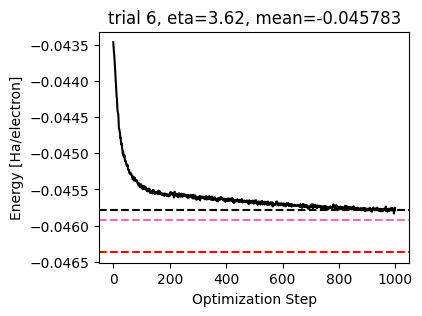

7.268127945451535 -0.0452915422


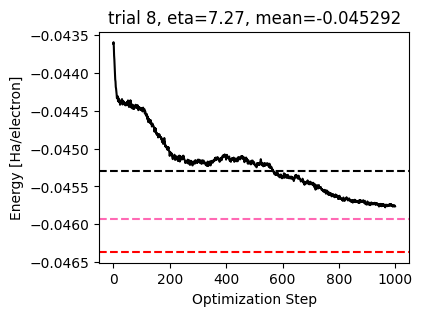

13.08163043199939 -0.0460881427


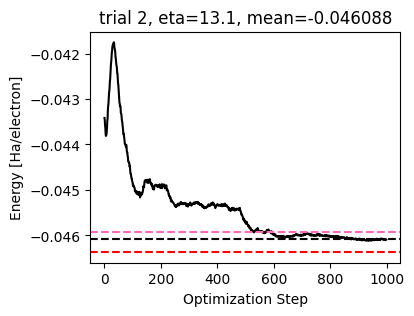

23.098008203667316 -0.0462040206


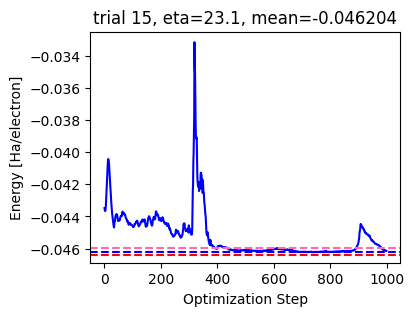

49.101649963458534 inf


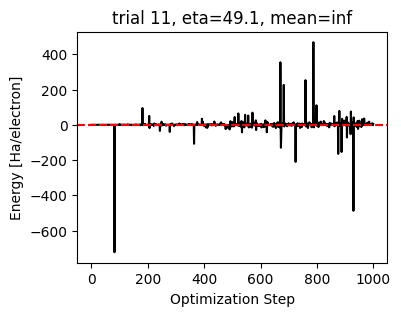

68.40846986686192 -0.045548433


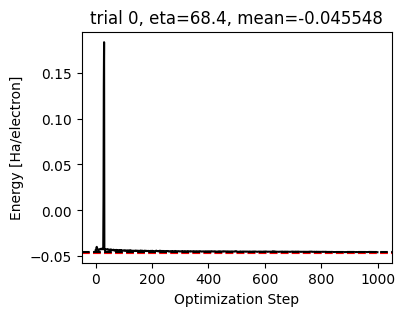

91.9171262178536 inf


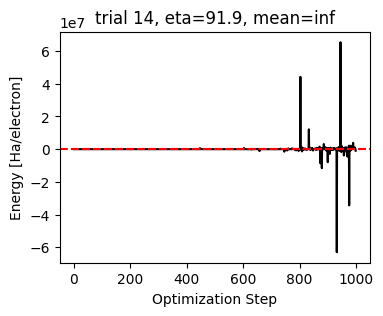

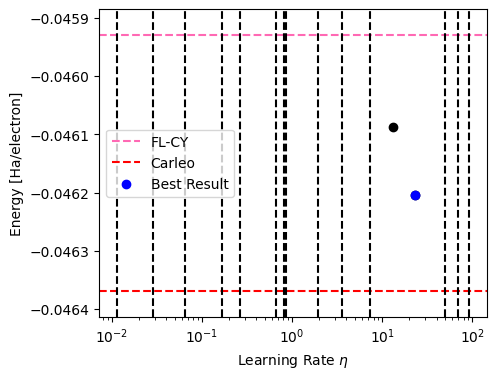

In [31]:
path = "joint/dynamic-smw/rs{}_trial{}/{}"
path = "joint/joint-dynamic-start-eye/rs{}_trial{}/{}"
path = "joint/joint-smw-thouless-noise/rs{}_trial{}/{}"

r_ws = "20"
dim = 2

PLOT_INDIVIDUAL_TRAJ = True

cmap = plt.cm.plasma
norm = mpl.colors.LogNorm(1e-2, 5e2)

final_vals = []
etas = []

if dim == 2:
    hard_vals = {
        "10" : ( -0.084474 , np.nan , np.nan ),
        "20" : ( -0.045929 , -0.045975 , -0.04637 ),
        "30" : ( -0.031689 , -0.031807 , -0.03197 ),
        "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
        "50" : ( -0.0196580 , np.nan , -0.019829 ),
    }
elif dim == 3:
    hard_vals = {
        "1" : ( 0.5780, np.nan, 0.568967 ),
        "2" : ( -0.00181, np.nan, -0.008391 ),
        "5" : ( -0.0764, np.nan, -0.0798544 ),
        "10" : ( -0.0534, np.nan, -0.0552126 ),
        "20" : ( -0.0316, np.nan, -0.0324553 ),
        "50" : ( -0.0143, np.nan, -0.01462631 ),
        "100" : ( -0.00760, np.nan, -0.00773018 ),
    }

for trial in range(16):

    try:
        
        eta = np.loadtxt(path.format(
            r_ws, str(trial), "hyperparameters.txt"
        ))
        etas.append(eta)
        
        (mean,_) = trajectory.getStatistics(path.format(
            r_ws, str(trial), "statistics.txt"
        ))
        
        energy_filename = path.format(
            r_ws, str(trial), "energy_traj.txt"
        )
        with open(energy_filename) as f:
            energy_traj = np.array([complex(line.strip()) for line in f])
        
        if mean is None:
            mean = np.inf
        final_vals.append((eta, mean, energy_traj))
    
    except:
        final_vals.append((eta, np.inf, None))

means = [j[1] for j in final_vals]
best_idx = np.argmin(means)
best_mean = means[best_idx]

if PLOT_INDIVIDUAL_TRAJ:

    eta_order = np.argsort(etas)

    for i in eta_order:
        
        eta = etas[i]
        _, mean, energy_traj = final_vals[i]

        if mean is None or energy_traj is None:
            print("eta = {} failed".format(eta))
            continue;
    
        print(eta, mean)

        ylim_range = hard_vals[r_ws][0] - hard_vals[r_ws][2]
        ylims = [ hard_vals[r_ws][2] - 0.1*ylim_range, hard_vals[r_ws][0] + 0.1*ylim_range ]

        if mean == best_mean:
            color = 'blue'
        else:
            color = 'black'

        plt.figure(figsize=(4,3))
        plt.plot(energy_traj, color=color)
        plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
        plt.axhline(y=hard_vals[r_ws][2], color='red', linestyle='--', label='SOTA')
        plt.axhline(y=mean, color=color, linestyle='--', label='Result')
        #plt.ylim(ylims)
        plt.title("trial {}, eta={:.3g}, mean={:.5g}".format(i, eta, mean))
        plt.xlabel("Optimization Step")
        plt.ylabel("Energy [Ha/electron]")
        plt.show()

else:

    eta, mean, energy_traj = final_vals[best_idx]
    energy_traj = np.real(energy_traj)

    ylim_range = hard_vals[r_ws][0] - hard_vals[r_ws][2]
    ylims = [ hard_vals[r_ws][2] - 0.1*ylim_range, hard_vals[r_ws][0] + 0.1*ylim_range ]
    
    plt.figure(figsize=(4,3))
    plt.plot(energy_traj, color='black', label='Result')
    plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
    plt.axhline(y=hard_vals[r_ws][2], color='red', linestyle='--', label='Carleo')
    plt.axhline(y=mean, color='black', linestyle='--')
    plt.ylim(ylims)
    plt.title("r_ws={}, eta={:.3g}, E={:.5g}".format(r_ws, eta, mean))
    plt.xlabel("Optimization Step")
    plt.ylabel("Energy [Ha/electron]")
    plt.legend()
    plt.show()

plt.figure(figsize=(5,4))

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='red', linestyle='--', label='Carleo')

ylim_range = hard_vals[r_ws][0] - hard_vals[r_ws][2]
ylims = [ hard_vals[r_ws][2] - 0.1*ylim_range, hard_vals[r_ws][0] + 0.1*ylim_range ]

for (eta, mean, energy_traj) in final_vals:
    if mean is None or mean > ylims[1] or mean < ylims[0]:
        plt.axvline(x=eta, color='black', linestyle='--')
    else:
        plt.scatter([eta], [mean], color='black')

means = [j[1] for j in final_vals]
idx = np.argmin(means)
plt.scatter(final_vals[idx][0], final_vals[idx][1], color='blue', label='Best Result')

plt.ylim(ylims)
plt.xscale('log')
plt.xlabel(r"Learning Rate $\eta$")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

57.545092223895686 None
0.030487744466204017 0.570566566
0.20324240336532898 0.56917913
0.2905128326935245 0.56919333
5.404995709687086 1.86975316
0.6464883206334968 0.680998164
0.0156526353699295 0.569314402
1.2695990326610214 0.691559838
0.5172070265743356 0.639965982
0.6491168727395806 0.66388212
97.38623783150939 None
0.023379505882175463 0.569301281
3.0269291142355566 0.720274732
0.2761533133950843 0.569161413


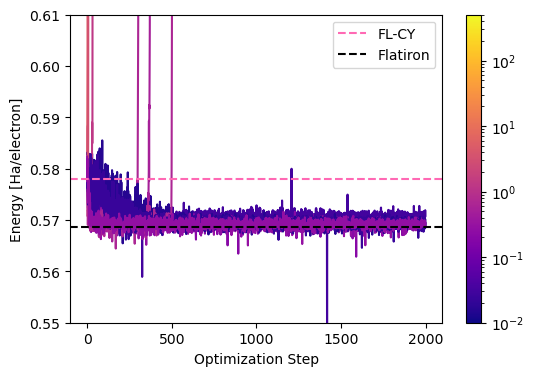

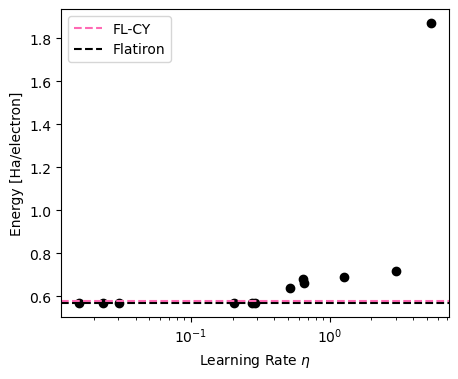

In [ ]:
path = "gaussian-reference/MP-init-gaussian/rs{}_trial{}/{}"
path = "salamander/NSJB-FL/rs{}_trial{}/{}"
path = "salamander/nomom/rs{}_trial{}/{}"
path = "rat/nomom/rs{}_trial{}/{}"

r_ws = "1"

cmap = plt.cm.plasma
norm = mpl.colors.LogNorm(1e-2, 5e2)

final_vals = []

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "1" : ( 0.5780, np.nan, 0.56861 ),
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for trial in range(16):
        
    eta = np.loadtxt(path.format(
        r_ws, str(trial), "hyperparameters.txt"
    ))

    try:
        energy_traj = np.loadtxt(path.format(
            r_ws, str(trial), "energy_traj.txt"
        ))

    except:
        final_vals.append([eta, None])
        continue;

    (mean,_) = trajectory.getStatistics(path.format(
        r_ws, str(trial), "statistics.txt"
    ))
    final_vals.append([eta, mean])

    print(eta, mean)

    if mean is None:
        continue;
    
    color = cmap(norm(eta))
    plt.plot(energy_traj, color=color)

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

min_val = np.nanmin([hard_vals[r_ws][0],hard_vals[r_ws][2]])
max_val = np.nanmax([hard_vals[r_ws][0],hard_vals[r_ws][2]])
#plt.ylim([1.1*min_val,0.9*max_val])

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # older matplotlib compatibility
cbar = plt.colorbar(sm, ax=plt.gca())

if r_ws == "10":
    plt.ylim([-0.09, -0.08])
elif r_ws == "20":
    plt.ylim([-0.047, -0.045])
elif r_ws == "30":
    plt.ylim([-0.0325, -0.0315])
elif r_ws == "50":
    plt.ylim([-0.01984, -0.019625])
elif r_ws == "1":
    plt.ylim([0.55, 0.61])
else:
    raise Exception()

plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

final_vals = np.array(final_vals)

plt.figure(figsize=(5,4))
plt.scatter(final_vals[:,0], final_vals[:,1], color='black')
plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')
plt.xscale('log')
plt.xlabel(r"Learning Rate $\eta$")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

### Compare best runs

CYJastrow	-0.0196580399
MP	-0.019774959
gaussian	-0.0197740944


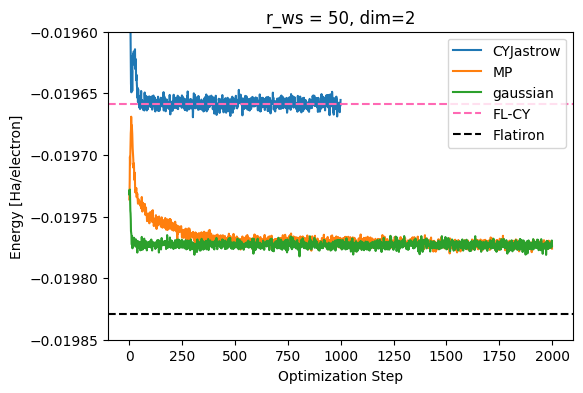

In [16]:
path = "{}/rs{}_best/{}"

r_ws = "50"
compare_vals = [
    ( "gaussian-reference/CYJastrow" , "CYJastrow" ),
    ( "gaussian-reference/MP-init-gaussian" , "MP" ),
    ( "gaussian-reference/gaussian" , "gaussian" ),
]

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for (filename, label) in compare_vals:

    energy_traj = np.loadtxt(path.format(
        filename, r_ws, "energy_traj.txt"
    ))

    (mean,_) = trajectory.getStatistics(path.format(
        filename, r_ws, "statistics.txt"
    ))

    print("{}\t{}".format(label, mean))

    if mean is None:
        continue;
    
    plt.plot(energy_traj, label=label)

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

if r_ws == "10":
    plt.ylim([-0.09, -0.08])
elif r_ws == "20":
    plt.ylim([-0.047, -0.045])
elif r_ws == "30":
    plt.ylim([-0.0325, -0.0315])
elif r_ws == "50":
    plt.ylim([-0.01985, -0.0196])
else:
    raise Exception()

plt.title("r_ws = {}, dim=2".format(r_ws))
plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

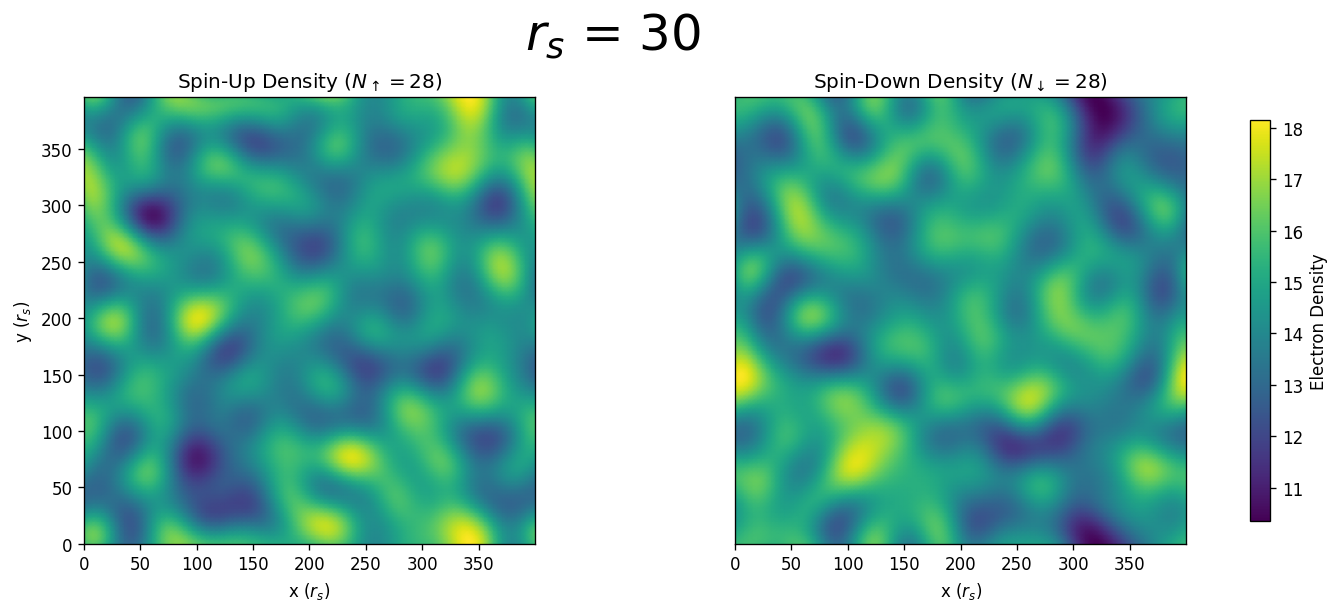

In [33]:
importlib.reload(wavefunctions)

path = "joint/joint-smw-thouless-noise/rs{}_best/parameters.msgpack"
static_type = "thouless"

r_ws = 30

N = 56
dim = 2
numKpts = 169

NUp = N // 2
NDown = N - NUp
spins = ( NUp , NDown )

lattice = wavefunctions.computeLattice(
    N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
)
rec_lattice = jnp.linalg.inv(lattice)
kpoints = wavefunctions.genKpoints(numKpts, lattice, dim)

parameters = wavefunctions.loadParameters(path.format(str(r_ws)))

if static_type == 'mp':
    
    upCoeffs = parameters['params']['slaterUp']['MP_coefficients']
    downCoeffs = parameters['params']['slaterDown']['MP_coefficients']

elif static_type == 'thouless':
    
    upRotation = parameters['params']['slaterUp']['thouless_rotation'].T
    downRotation = parameters['params']['slaterDown']['thouless_rotation'].T

    upCoeffs = wavefunctions.occ_columns_from_theta(upRotation)
    downCoeffs = wavefunctions.occ_columns_from_theta(downRotation)

else:
    raise Exception("Unknown wavefunction type...")

Nk = kpoints.shape[0]
cos = jnp.zeros(Nk).at[0].set(1.0)
cos = cos.at[jnp.arange(1, Nk, 2)].set(1.0)
cos_switch = cos
sin_switch = 1.0 - cos

def eval_basis_at_point(r):
    dot_vals = jnp.dot(kpoints, r)
    terms = cos_switch * jnp.cos(dot_vals) + sin_switch * jnp.sin(-dot_vals)
    return terms

# 3. Generate Grid
n_grid = 100
u = jnp.linspace(0, 1, n_grid)
v = jnp.linspace(0, 1, n_grid)
uu, vv = jnp.meshgrid(u, v) 
flat_frac = jnp.stack([uu.ravel(), vv.ravel()], axis=-1)
flat_real = flat_frac @ lattice 

# 4. Compute Densities
# Evaluate basis: (N_grid, N_k)
basis_vals = jax.vmap(eval_basis_at_point)(flat_real) 

# Calculate Up Orbitals: (N_grid, N_k) @ (N_k, N_up) -> (N_grid, N_up)
orbitals_up = jnp.dot(basis_vals, upCoeffs)
# Calculate Down Orbitals: (N_grid, N_k) @ (N_k, N_down) -> (N_grid, N_down)
orbitals_down = jnp.dot(basis_vals, downCoeffs)

"""
# Sum squares to get density
rho_up = jnp.sum(orbitals_up**2, axis=1).reshape(n_grid, n_grid)
rho_down = jnp.sum(orbitals_down**2, axis=1).reshape(n_grid, n_grid)
"""

# Take care of the fact that MP coefficients are not normalized
# (Above code was previous approach, which ignored this issue)
S_up   = upCoeffs.T   @ upCoeffs    # (NUp, NUp)
S_down = downCoeffs.T @ downCoeffs  # (NDown, NDown)

S_up_inv   = jnp.linalg.inv(S_up)
S_down_inv = jnp.linalg.inv(S_down)

rho_up   = jnp.einsum('gi,ij,gj->g', orbitals_up,   S_up_inv,   orbitals_up).reshape(n_grid, n_grid)
rho_down = jnp.einsum('gi,ij,gj->g', orbitals_down, S_down_inv, orbitals_down).reshape(n_grid, n_grid)

# 5. Plot Side-by-Side
# Grid coordinates for plotting
grid_real = (jnp.stack([uu, vv], axis=-1) @ lattice)
X_plot = grid_real[:, :, 0]
Y_plot = grid_real[:, :, 1]

# Determine global min/max for shared colorbar
vmin = min(rho_up.min(), rho_down.min())
vmax = max(rho_up.max(), rho_down.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, constrained_layout=True)

# Plot Up
im1 = axes[0].pcolormesh(X_plot, Y_plot, rho_up, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f"Spin-Up Density ($N_{{\\uparrow}}={NUp}$)")
axes[0].set_aspect('equal')
axes[0].set_xlabel("x ($r_s$)")
axes[0].set_ylabel("y ($r_s$)")

# Plot Down
im2 = axes[1].pcolormesh(X_plot, Y_plot, rho_down, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f"Spin-Down Density ($N_{{\\downarrow}}={NDown}$)")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x ($r_s$)")
axes[1].set_yticks([]) # Hide Y ticks for the second plot

# Shared Colorbar
fig.colorbar(im2, ax=axes, label="Electron Density", fraction=0.05, shrink=0.9)
plt.suptitle(f"$r_s$ = " + str(r_ws), fontsize=30)
plt.show()

[[-1.7358807e-03 -1.6457117e-04 -8.8641909e-04 ... -2.5226739e-03
  -1.9430992e-03 -6.0909305e-04]
 [ 8.0817204e-04  1.3074768e-03  1.9727715e-03 ...  4.9002224e-04
  -1.0727153e-03  5.1029783e-04]
 [-7.9443597e-04 -1.1953752e-03  6.6631584e-04 ...  8.1948290e-04
   9.8172680e-04 -4.5513629e-04]
 ...
 [-1.2685399e-03  9.5552055e-04 -1.2449746e-05 ... -1.2163715e-03
   8.8050845e-05  9.2362607e-05]
 [-1.1896970e-03 -7.4663467e-04  7.7736558e-04 ... -3.9737101e-04
   1.8096273e-04 -7.0308521e-04]
 [ 1.2546532e-03  3.0895439e-04  4.1665795e-04 ... -2.4194228e-03
  -1.4084474e-03 -3.7800265e-04]]

[[ 1.7154173e-03 -9.9434576e-04 -4.4000294e-04 ...  6.0989091e-04
   9.1777788e-04  2.8593189e-04]
 [ 4.9322302e-04 -1.4812220e-03 -7.2215195e-04 ... -1.5023915e-04
  -4.4551745e-04  4.9145857e-04]
 [ 4.1613178e-04  5.6649867e-04  3.4988596e-04 ...  7.4003183e-05
  -3.0239401e-04  1.6080649e-03]
 ...
 [-4.6934985e-04  1.0636144e-03 -2.6341394e-04 ...  4.6346721e-04
  -6.6268822e-04 -1.3646169e-03

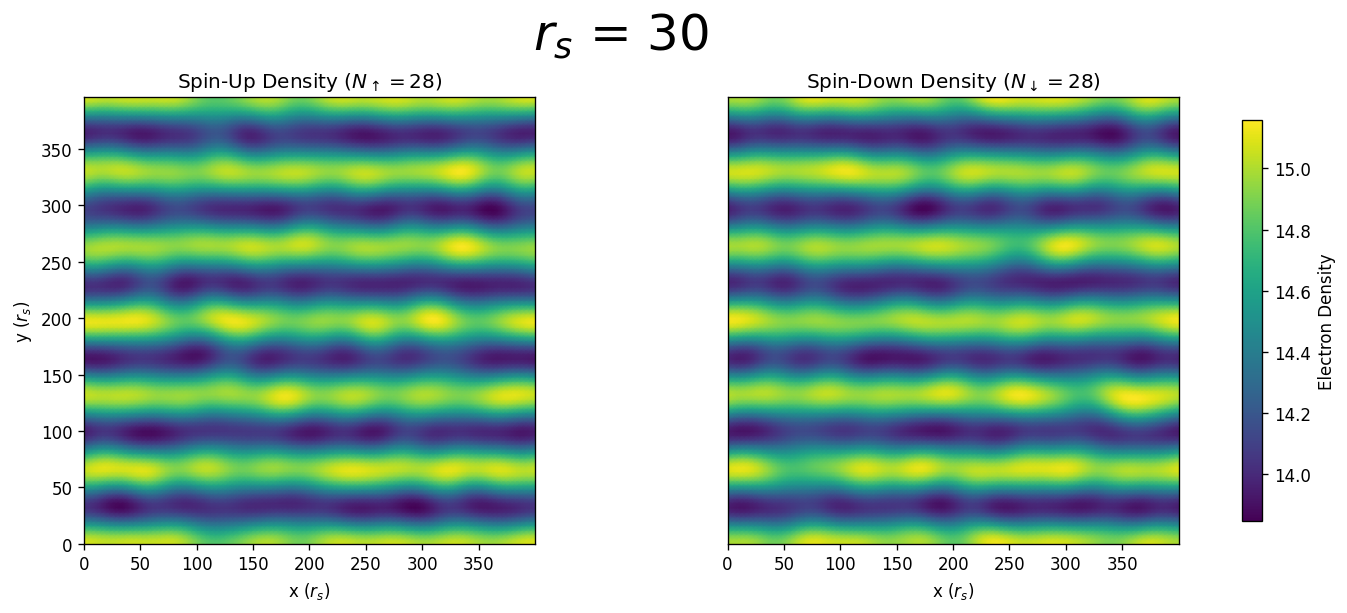

In [45]:
spins = (28,28)
numKpoints = 169

coeffShape = (numKpoints, spins[0])
thouless_noise = 1e-3
upCoeffs = jnp.eye(numKpoints, spins[0]) + thouless_noise * np.random.normal(size=coeffShape)
downCoeffs = jnp.eye(numKpoints, spins[1]) + thouless_noise * np.random.normal(size=coeffShape)

print(wavefunctions.theta_from_occ_columns(upCoeffs))
print()
print(wavefunctions.theta_from_occ_columns(downCoeffs))
print()
print("REST:")

Nk = kpoints.shape[0]
cos = jnp.zeros(Nk).at[0].set(1.0)
cos = cos.at[jnp.arange(1, Nk, 2)].set(1.0)
cos_switch = cos
sin_switch = 1.0 - cos

def eval_basis_at_point(r):
    dot_vals = jnp.dot(kpoints, r)
    terms = cos_switch * jnp.cos(dot_vals) + sin_switch * jnp.sin(-dot_vals)
    return terms

# 3. Generate Grid
n_grid = 100
u = jnp.linspace(0, 1, n_grid)
v = jnp.linspace(0, 1, n_grid)
uu, vv = jnp.meshgrid(u, v) 
flat_frac = jnp.stack([uu.ravel(), vv.ravel()], axis=-1)
flat_real = flat_frac @ lattice 

# 4. Compute Densities
# Evaluate basis: (N_grid, N_k)
basis_vals = jax.vmap(eval_basis_at_point)(flat_real) 

# Calculate Up Orbitals: (N_grid, N_k) @ (N_k, N_up) -> (N_grid, N_up)
orbitals_up = jnp.dot(basis_vals, upCoeffs)
# Calculate Down Orbitals: (N_grid, N_k) @ (N_k, N_down) -> (N_grid, N_down)
orbitals_down = jnp.dot(basis_vals, downCoeffs)

"""
# Sum squares to get density
rho_up = jnp.sum(orbitals_up**2, axis=1).reshape(n_grid, n_grid)
rho_down = jnp.sum(orbitals_down**2, axis=1).reshape(n_grid, n_grid)
"""

# Take care of the fact that MP coefficients are not normalized
# (Above code was previous approach, which ignored this issue)
S_up   = upCoeffs.T   @ upCoeffs    # (NUp, NUp)
S_down = downCoeffs.T @ downCoeffs  # (NDown, NDown)

S_up_inv   = jnp.linalg.inv(S_up)
S_down_inv = jnp.linalg.inv(S_down)

rho_up   = jnp.einsum('gi,ij,gj->g', orbitals_up,   S_up_inv,   orbitals_up).reshape(n_grid, n_grid)
rho_down = jnp.einsum('gi,ij,gj->g', orbitals_down, S_down_inv, orbitals_down).reshape(n_grid, n_grid)

# 5. Plot Side-by-Side
# Grid coordinates for plotting
grid_real = (jnp.stack([uu, vv], axis=-1) @ lattice)
X_plot = grid_real[:, :, 0]
Y_plot = grid_real[:, :, 1]

# Determine global min/max for shared colorbar
vmin = min(rho_up.min(), rho_down.min())
vmax = max(rho_up.max(), rho_down.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, constrained_layout=True)

# Plot Up
im1 = axes[0].pcolormesh(X_plot, Y_plot, rho_up, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f"Spin-Up Density ($N_{{\\uparrow}}={NUp}$)")
axes[0].set_aspect('equal')
axes[0].set_xlabel("x ($r_s$)")
axes[0].set_ylabel("y ($r_s$)")

# Plot Down
im2 = axes[1].pcolormesh(X_plot, Y_plot, rho_down, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f"Spin-Down Density ($N_{{\\downarrow}}={NDown}$)")
axes[1].set_aspect('equal')
axes[1].set_xlabel("x ($r_s$)")
axes[1].set_yticks([]) # Hide Y ticks for the second plot

# Shared Colorbar
fig.colorbar(im2, ax=axes, label="Electron Density", fraction=0.05, shrink=0.9)
plt.suptitle(f"$r_s$ = " + str(r_ws), fontsize=30)
plt.show()